# Binary Dependent Variables: LPM, Logit & Probit. Lecture Notebook
### Applied Statistical Data Analysis. Prof. Dr. Kristyna Ters | MSc Finance | FHNW
**Based on:** Brooks, C., *Introductory Econometrics for Finance*, Cambridge University Press, Ch. 12

---
**Learning Objectives:**
- Understand why OLS struggles with 0/1 outcomes (the **LPM** and its defects)
- Estimate **logit** and **probit** models by maximum likelihood
- Interpret coefficients via **marginal effects** and **odds factors**
- Compute **default probabilities (PD)** per borrower with a probit
- Evaluate binary models with **pseudo-R-squared** and **hit rates**

> Run each cell with **Shift+Enter**. This notebook accompanies the lecture slides of this module.
> Both datasets are fixed simulated teaching files, published with the module and built so that
> the estimates land exactly on the values printed on the slides. Every number of this chapter is
> therefore reproducible here, digit for digit.

## Step 0: Install & Import Libraries

In [1]:
!pip install statsmodels --quiet

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.alpha':0.3, 'font.size':11
})
YELLOW = '#FDE70E'; ORANGE = '#FCB310'; RED = '#C70101'
GREY   = '#4B4B4B'; BLUE = '#0E75FE'; GREEN = '#0B7A3C'
print('Libraries loaded.')

Libraries loaded.


---
# Part 1: The Dividend Cross-Section

The running example of the video: **which firms pay dividends?** The cross-section is a fixed
teaching dataset of 500 simulated US-style firms with three characteristics: profitability (ROA in
percent), size (market capitalisation in USD millions, logged here) and leverage (debt over assets,
as a share between 0 and 1).

Fund- and firm-level dividend data are licensed, so the file is simulated, but not drawn at random.
The payer column was *constructed* so that the maximum likelihood estimates land on the coefficients
printed on the slides, and so that the log-likelihood, the pseudo-R² and the whole confusion matrix
come out as the video states them. Its header says so. That is what lets you reproduce every number
of this chapter exactly; on real data, estimate and parameter never coincide like this.

### 1.1 Load the sample

In [2]:
# The dividend cross-section: a FIXED teaching dataset, built so that the
# estimated logit is the one on the slides. See the file header for how and why.
DIV_CSV = ('https://raw.githubusercontent.com/KristynaTers/ASDA/main/data/'
           'ASDA_DividendPayers_Teaching_2026.csv')

div = pd.read_csv(DIV_CSV, comment='#')
df = pd.DataFrame({'payer': div['payer'].astype(float),
                   'roa': div['roa_pct'],
                   'ln_mcap': np.log(div['mcap_usd_m']),
                   'leverage': div['leverage']})
print(df.describe().round(3))
print(f"\nPayers: {int(df['payer'].sum())} of {len(df)}  ({df['payer'].mean():.1%})")

         payer      roa  ln_mcap  leverage
count  500.000  500.000  500.000   500.000
mean     0.620    8.001   10.909     0.311
std      0.486    7.743    1.685     0.161
min      0.000  -13.849    6.342     0.027
25%      0.000    2.218    9.731     0.184
50%      1.000    7.713   10.868     0.289
75%      1.000   13.483   12.110     0.424
max      1.000   30.401   14.979     0.830

Payers: 310 of 500  (62.0%)


**Check the benchmark first.** The unconditional payer share is about 62 percent. That number
does double duty: it is the probability the constant-only model assigns to everyone, and it is
the hit rate of the naive strategy "predict payer for every firm". Every model below must beat it.

The odds of paying: 0.62/0.38 is about 1.63 to one, i.e. paying is 1.63 times as likely as not
paying. Odds return as the natural language of logit coefficients in Part 4.

---
# Part 2: The Linear Probability Model, Briefly

Just run OLS on the 0/1 outcome. Each coefficient is then a probability change per unit of x.
Legitimate as a quick first look, but watch its three defects: predictions outside [0, 1],
built-in heteroskedasticity (the error variance of a 0/1 outcome is p(1 minus p) by construction,
so robust standard errors are mandatory), and constant effects everywhere on the probability scale.

### 2.1 Fit the LPM with robust standard errors

In [3]:
X = sm.add_constant(df[['roa', 'ln_mcap', 'leverage']])
lpm = sm.OLS(df['payer'], X).fit(cov_type='HC1')   # White robust SEs, as in the diagnostics video
print(lpm.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8838      0.114     -7.787      0.000      -1.106      -0.661
roa            0.0146      0.002      6.066      0.000       0.010       0.019
ln_mcap        0.1375      0.009     14.762      0.000       0.119       0.156
leverage      -0.3603      0.110     -3.287      0.001      -0.575      -0.145


In [4]:
fitted = lpm.fittedvalues
n_above = (fitted > 1).sum()
n_below = (fitted < 0).sum()
print(f"Fitted values outside [0, 1]: {n_above} above 1, {n_below} below 0")
print(f"Range of fitted values: {fitted.min():.3f} to {fitted.max():.3f}")

Fitted values outside [0, 1]: 42 above 1, 4 below 0
Range of fitted values: -0.078 to 1.350


**Reading.** The LPM slope on ROA says: one more point of ROA adds about 1.5 percentage points of
payer probability, for every firm alike. Keep the LPM coefficients in mind; they approximate the
average marginal effects of Part 5, which is the sense in which the LPM is a decent first look.
The out-of-band predictions are the broken part: the fitted values above run up to 1.35 and down
to minus 0.08, and neither is a probability.

---
# Part 3: Logit & Probit

Keep the linear index x'beta, but pass it through a CDF so the result always lands in (0, 1):
the logistic CDF gives the **logit**, the standard normal CDF gives the **probit**. Estimation is
by maximum likelihood: choose the betas that make the observed 0/1 pattern most probable.
Inference works through z-statistics (asymptotic normality), compared with 1.96 exactly like
t-statistics in large samples.

### 3.1 Fit both models

In [5]:
logit = sm.Logit(df['payer'], X).fit(disp=0)
probit = sm.Probit(df['payer'], X).fit(disp=0)
print(logit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.5585      0.965     -8.865      0.000     -10.451      -6.666
roa            0.0896      0.016      5.571      0.000       0.058       0.121
ln_mcap        0.8454      0.088      9.619      0.000       0.673       1.018
leverage      -2.0698      0.705     -2.937      0.003      -3.451      -0.689


In [6]:
compare = pd.DataFrame({
    'logit': logit.params.round(3),
    'probit': probit.params.round(3),
    'ratio logit/probit': (logit.params/probit.params).round(2),
})
print(compare)

# Do not assert the scale factor, read it off the estimates:
r = (logit.params/probit.params)
print(f"\nScale factor logit/probit: {r.min():.2f} to {r.max():.2f} (mean {r.mean():.2f}).")
print("Two conventions produce such a factor, and BOTH are coefficient factors:")
print(f"  equal latent error variances  -> pi/sqrt(3)    = {np.pi/np.sqrt(3):.2f}"
      "   (what these estimates follow)")
print(f"  equal marginal effect at P=0.5 -> phi(0)/0.25   = {norm.pdf(0)/0.25:.2f}"
      "   (the familiar '1.6 rule')")

# What the rescaling does NOT touch: the marginal effects themselves.
ame_l = logit.get_margeff(at='overall').margeff
ame_p = probit.get_margeff(at='overall').margeff
print("\nThe marginal effects agree either way:")
print(pd.DataFrame({'AME logit': ame_l.round(4), 'AME probit': ame_p.round(4),
                    'ratio': (ame_l/ame_p).round(3)}, index=X.columns[1:]))
print("So the logit/probit choice rescales the betas, not the conclusions.")

          logit  probit  ratio logit/probit
const    -8.559  -4.850                1.76
roa       0.090   0.050                1.79
ln_mcap   0.845   0.480                1.76
leverage -2.070  -1.172                1.77

Scale factor logit/probit: 1.76 to 1.79 (mean 1.77).
Two conventions produce such a factor, and BOTH are coefficient factors:
  equal latent error variances  -> pi/sqrt(3)    = 1.81   (what these estimates follow)
  equal marginal effect at P=0.5 -> phi(0)/0.25   = 1.60   (the familiar '1.6 rule')

The marginal effects agree either way:
          AME logit  AME probit  ratio
roa          0.0141      0.0137  1.028
ln_mcap      0.1328      0.1314  1.011
leverage    -0.3252     -0.3208  1.014
So the logit/probit choice rescales the betas, not the conclusions.


**Reading the table.** Signs and significance first, that reading is always safe: profitable and
large firms pay, heavily levered firms do not, and all three z-statistics clear 1.96. The raw
logit betas are INDEX effects, not probability effects; how much the probability moves depends on
where the firm sits on the S-curve. Hence the two translation languages of the next two parts:
odds factors and marginal effects.

---
# Part 4: The Odds Language

Odds are P/(1 minus P). In the logit, odds equal e to the power x'beta EXACTLY, so each unit of a
regressor multiplies the odds by the constant factor e to the beta. This exactness is why logit
results can be communicated in odds language (and probit results cannot).

### 4.1 Odds factors

In [7]:
odds_factors = np.exp(logit.params)
tab = pd.DataFrame({'coefficient': logit.params.round(3),
                    'odds factor e^beta': odds_factors.round(3)})
print(tab)

b_roa = logit.params['roa']
b_lev = logit.params['leverage']
print(f"\nEach ROA point multiplies the odds of paying by {np.exp(b_roa):.3f}"
      f"  (+{(np.exp(b_roa)-1)*100:.1f} percent)")
print(f"A 10-point leverage increase multiplies the odds by {np.exp(b_lev*0.10):.3f}"
      f"  ({(np.exp(b_lev*0.10)-1)*100:.1f} percent)")

          coefficient  odds factor e^beta
const          -8.559               0.000
roa             0.090               1.094
ln_mcap         0.845               2.329
leverage       -2.070               0.126

Each ROA point multiplies the odds of paying by 1.094  (+9.4 percent)
A 10-point leverage increase multiplies the odds by 0.813  (-18.7 percent)


**Two-step discipline for the leverage number:** coefficient TIMES the change first (minus 2.1
times 0.10), exponentiate second. Exponentiating the raw coefficient would answer a 0-to-1 jump of
leverage, i.e. 100 percentage points, not 10. And remember the log regressor: the 0.85 on ln(mcap)
reads as an elasticity of the odds, roughly +0.85 percent odds per 1 percent more market cap.

---
# Part 5: Marginal Effects, What You Should Report

Chain rule: the probability effect of x is the coefficient times the slope of the S-curve at the
firm's position, for the logit simply P(1 minus P). The reporting standard is the **average
marginal effect (AME)**: compute the effect for every firm, then average.

### 5.1 AME in one line

In [8]:
ame = logit.get_margeff(at='overall')
print(ame.summary())

        Logit Marginal Effects       
Dep. Variable:                  payer
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
roa            0.0141      0.002      6.288      0.000       0.010       0.018
ln_mcap        0.1328      0.008     15.863      0.000       0.116       0.149
leverage      -0.3252      0.107     -3.032      0.002      -0.535      -0.115


In [9]:
ame_tab = pd.DataFrame({'AME': ame.margeff.round(4),
                        'LPM coefficient': lpm.params.drop('const').round(4).values},
                       index=['roa', 'ln_mcap', 'leverage'])
print(ame_tab)
print("\nThe LPM coefficients approximate the AME: that is the precise sense in which")
print("the LPM is a legitimate quick look.")

             AME  LPM coefficient
roa       0.0141           0.0146
ln_mcap   0.1328           0.1375
leverage -0.3252          -0.3603

The LPM coefficients approximate the AME: that is the precise sense in which
the LPM is a legitimate quick look.


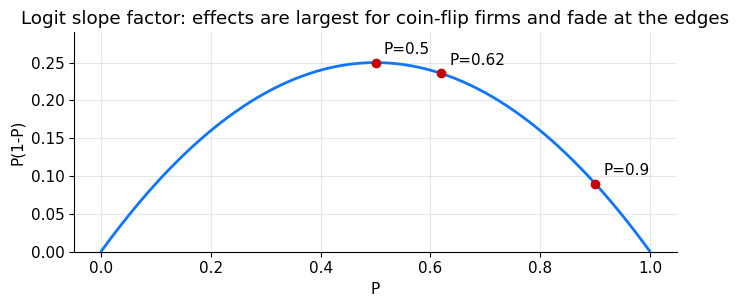

In [10]:
# The slope factor P(1-P): a bell that peaks at P = 0.5
P = np.linspace(0.001, 0.999, 300)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(P, P*(1-P), color=BLUE, lw=2)
for pt in [0.5, 0.62, 0.9]:
    ax.scatter([pt], [pt*(1-pt)], color=RED, zorder=5)
    ax.annotate(f"P={pt}", (pt, pt*(1-pt)), textcoords='offset points', xytext=(6, 6))
ax.set_ylim(0, 0.29)
ax.set_xlabel('P'); ax.set_ylabel('P(1-P)')
ax.set_title('Logit slope factor: effects are largest for coin-flip firms and fade at the edges')
plt.tight_layout(); plt.show()

---
# Part 6: Second Example, Default Probabilities (PD)

Credit risk is where these models live in practice. The second fixed teaching file holds 2000
corporate borrowers with leverage and interest coverage (ICR = EBIT over interest expense); its
default column was built from a probit with the lecture's coefficients, so the fit below returns
them: PD = Phi(minus 1.65 + 2.0 leverage minus 0.10 ICR). The probit convention (normal CDF Phi)
is standard in credit-risk and Basel IRB work.

### 6.1 Load and fit

In [11]:
# The borrower panel: the second fixed teaching dataset of this module.
BOR_CSV = ('https://raw.githubusercontent.com/KristynaTers/ASDA/main/data/'
           'ASDA_CorporateDefaults_Teaching_2026.csv')

bor = pd.read_csv(BOR_CSV, comment='#')
borrowers = pd.DataFrame({'default': bor['default'].astype(float),
                          'leverage': bor['leverage'], 'icr': bor['icr']})
m = len(borrowers)
print(f"Defaults: {int(borrowers['default'].sum())} of {m}  "
      f"({borrowers['default'].mean():.1%})")

Xb = sm.add_constant(borrowers[['leverage', 'icr']])
pd_probit = sm.Probit(borrowers['default'], Xb).fit(disp=0)
print(pd_probit.summary().tables[1])

Defaults: 60 of 2000  (3.0%)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6495      0.223     -7.406      0.000      -2.086      -1.213
leverage       2.0003      0.501      3.990      0.000       1.018       2.983
icr           -0.1000      0.019     -5.298      0.000      -0.137      -0.063


### 6.2 The deliverable: a PD per borrower

The fitted probability itself is the answer. Two example borrowers from the slides:
borrower A (leverage 0.20, ICR 8) and borrower B (leverage 0.65, ICR 1.5).

In [12]:
examples = pd.DataFrame({'leverage': [0.20, 0.65], 'icr': [8.0, 1.5]}, index=['A', 'B'])
Xe = sm.add_constant(examples, has_constant='add')

pd_hat = pd_probit.predict(Xe)
index_slide = -1.65 + 2.0*examples['leverage'] - 0.10*examples['icr']
pd_slide = norm.cdf(index_slide)

out = pd.DataFrame({'index (slide coefficients)': index_slide.round(2),
                    'PD (slide coefficients)': (pd_slide*100).round(1),
                    'PD (fitted model)': (pd_hat*100).round(1)})
out.columns = ['index', 'PD slide (%)', 'PD fitted (%)']
print(out)
print("\nBorrower B pays a far higher spread than borrower A: this number drives loan")
print("pricing, rating grades and regulatory capital (Basel IRB).")

   index  PD slide (%)  PD fitted (%)
A  -2.05           2.0            2.0
B  -0.50          30.9           30.9

Borrower B pays a far higher spread than borrower A: this number drives loan
pricing, rating grades and regulatory capital (Basel IRB).


---
# Part 7: How Good Is the Model? Pseudo-R-squared and Hit Rates

No residual variance, no ordinary R-squared. The ML yardstick is the log-likelihood: McFadden's
pseudo-R-squared compares the fitted model with the constant-only model. Values of 0.2 to 0.4
already indicate a strong binary model, and it is NOT explained variance.

### 7.1 McFadden for the dividend logit

In [13]:
print(f"log-likelihood fitted model : {logit.llf:.1f}")
print(f"log-likelihood constant-only: {logit.llnull:.1f}")
print(f"McFadden pseudo-R2          : {logit.prsquared:.3f}")

log-likelihood fitted model : -239.0
log-likelihood constant-only: -332.0
McFadden pseudo-R2          : 0.280


### 7.2 The confusion table and hit rate (cutoff 0.5)

In [14]:
pred = (logit.predict(X) > 0.5).astype(int)
conf = pd.crosstab(df['payer'], pred, rownames=['actual'], colnames=['predicted'])
print(conf)

hit = (pred == df['payer']).mean()
naive = df['payer'].mean()
print(f"\nHit rate : {hit:.1%}")
print(f"Naive    : {naive:.1%}  (predict 'payer' for everyone)")
print(f"Payers caught    : {conf.loc[1, 1] / conf.loc[1].sum():.1%}")
print(f"Non-payers caught: {conf.loc[0, 0] / conf.loc[0].sum():.1%}")

predicted    0    1
actual             
0.0        125   65
1.0         45  265

Hit rate : 78.0%
Naive    : 62.0%  (predict 'payer' for everyone)
Payers caught    : 85.5%
Non-payers caught: 65.8%


### 7.3 The unbalanced-sample trap, live

Apply the same cutoff-0.5 logic to the PD sample with its 3 percent event rate and watch the
headline hit rate mislead.

In [15]:
pred_b = (pd_probit.predict(Xb) > 0.5).astype(int)
print(f"Predicted defaults at cutoff 0.5: {pred_b.sum()} of {m}")
print(f"Hit rate  : {(pred_b == borrowers['default']).mean():.1%}")
print(f"Naive     : {1 - borrowers['default'].mean():.1%}  (predict 'no default' for everyone)")
caught = ((pred_b == 1) & (borrowers['default'] == 1)).sum()
print(f"Defaulters caught: {caught} of {int(borrowers['default'].sum())}")

# a cutoff at the sample share catches far more defaulters, at the cost of false alarms
cut = borrowers['default'].mean()
pred_c = (pd_probit.predict(Xb) > cut).astype(int)
caught_c = ((pred_c == 1) & (borrowers['default'] == 1)).sum()
false_c = ((pred_c == 1) & (borrowers['default'] == 0)).sum()
print(f"\nCutoff at the sample share ({cut:.3f}):")
print(f"Defaulters caught: {caught_c} of {int(borrowers['default'].sum())},"
      f"  false alarms: {false_c}")

Predicted defaults at cutoff 0.5: 0 of 2000
Hit rate  : 97.0%
Naive     : 97.0%  (predict 'no default' for everyone)
Defaulters caught: 0 of 60

Cutoff at the sample share (0.030):
Defaulters caught: 44 of 60,  false alarms: 693


**Read both rows, not just the total.** With rare events, the all-safe prediction scores a
near-perfect hit rate and is useless. Choose the cutoff from the cost ratio of the two errors;
in credit scoring, a missed default costs the loan, a false alarm costs a review.

---
# Summary

- For a 0/1 outcome the regression models a probability: E[y|x] = P(y=1|x)
- The LPM is a quick first look; its defects push us to logit and probit
- Maximum likelihood chooses the betas that make the observed pattern most probable; z-statistics
- Report average marginal effects, and odds factors e^beta where useful (logit only)
- The fitted probability is the deliverable: PD drives pricing, ratings, regulatory capital
- Evaluate with McFadden pseudo-R-squared and hit rates against the naive benchmark

**Reading:** Brooks, Chapter 12. **Next:** Time Series I, stationarity and unit roots.